# Crack-analysis pipeline Notebook

This notebook processes crack images using **YOLOv8 segmentation** as the primary detector.
A lightweight preprocessing step (grayscale + brightness/contrast normalisation) is applied
before inference so that YOLO works on a well-exposed image.  The resulting segmentation mask
is then passed to the geometric, width, and damage-feature stages.

**Pipeline order:**
1. Load image
2. Preprocess: grayscale → CLAHE brightness normalisation → convert back to BGR for YOLO
3. YOLOv8 segmentation inference → binary crack mask
4. Geometry, width, damage features derived from the YOLO mask


In [2]:
import os
import glob
import datetime
from pathlib import Path

import cv2
import numpy as np
from skimage.morphology import skeletonize
from scipy.ndimage import convolve, distance_transform_edt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from ultralytics import YOLO

%matplotlib inline

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
INPUT_DIR  = Path("test_images")
OUTPUT_DIR = Path("output")

YOLO_MODEL_PATH = "best-2.pt"
YOLO_CONF       = 0.20
YOLO_IOU        = 0.45
CRACK_CLASS_ID  = 0

# ── ACI structural significance threshold ────────────────────────────────
# ACI 224R / ACI 318: cracks narrower than 0.3 mm (≈ 3 px at typical rover
# standoff) are considered cosmetic / non-structural and are ignored.
# Adjust MM_PER_PIXEL to match your camera calibration; the pixel threshold
# is derived automatically from it.  If no calibration is available the
# raw pixel threshold ACI_MIN_WIDTH_PX is used directly.
ACI_MIN_WIDTH_MM = 3      # mm  – ACI 224R cosmetic crack limit
MM_PER_PIXEL     = None       # set e.g. 0.1 once calibrated; None = px only
ACI_MIN_WIDTH_PX = 3          # fallback pixel threshold when MM_PER_PIXEL=None

# Minimum mask area (px²) for a YOLO instance to be analysed at all.
# Eliminates tiny speckle detections before any geometry is computed.
MIN_INSTANCE_AREA_PX = 200


### Preprocessing (Grayscale + Brightness Normalisation)
Applied *before* YOLO inference to improve detection on dark or washed-out images.

In [3]:
def preprocess_for_yolo(image_bgr, *, clip_limit=2.0, tile_grid=(8, 8)):
    """
    Lightweight preprocessing applied before YOLO inference.

    Steps
    -----
    1. Convert BGR → grayscale.
    2. Apply CLAHE (Contrast Limited Adaptive Histogram Equalisation) to
       normalise local brightness variations – important for outdoor concrete
       imagery where illumination is uneven.
    3. Convert the enhanced grayscale back to BGR so YOLO receives a
       3-channel tensor (its expected input format).

    Parameters
    ----------
    image_bgr   : np.ndarray  Original BGR image from cv2.imread.
    clip_limit  : float       CLAHE clip limit (higher → more contrast boost).
    tile_grid   : tuple       CLAHE tile grid size.

    Returns
    -------
    preprocessed_bgr : np.ndarray  3-channel image ready for YOLO.
    gray_clahe       : np.ndarray  Single-channel CLAHE result (for display).
    """
    # Step 1 – grayscale
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

    # Step 2 – CLAHE brightness normalisation
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    gray_clahe = clahe.apply(gray)

    # Step 3 – back to 3-channel BGR for YOLO
    preprocessed_bgr = cv2.cvtColor(gray_clahe, cv2.COLOR_GRAY2BGR)

    return preprocessed_bgr, gray_clahe


### YOLOv8 Segmentation
Replaces the old threshold-based segmentation. The model is loaded once and
reused across all images in a session.

In [4]:
# Load the model once at module level so it is not reloaded for every image.
_yolo_model = None

def get_yolo_model():
    """Lazy-load and cache the YOLOv8 segmentation model."""
    global _yolo_model
    if _yolo_model is None:
        print(f"Loading YOLOv8 model from: {YOLO_MODEL_PATH}")
        _yolo_model = YOLO(YOLO_MODEL_PATH)
    return _yolo_model


def segment_crack_yolo(image_bgr, preprocessed_bgr, *,
                        conf=YOLO_CONF, iou=YOLO_IOU,
                        crack_class_id=CRACK_CLASS_ID):
    """
    Run YOLOv8 segmentation on the preprocessed image and return a binary mask.

    Parameters
    ----------
    image_bgr       : np.ndarray  Original image (used only for shape reference).
    preprocessed_bgr: np.ndarray  CLAHE-enhanced 3-channel image passed to YOLO.
    conf            : float       Confidence threshold.
    iou             : float       NMS IoU threshold.
    crack_class_id  : int         Class index that corresponds to 'crack'.
                                  Set to None to merge all detected classes.

    Returns
    -------
    mask       : np.ndarray uint8  Binary mask (255 = crack, 0 = background),
                                   same H×W as input image.
    result_img : np.ndarray        YOLO annotated BGR image (for display).
    n_detected : int               Number of crack instances found.
    """
    h, w = image_bgr.shape[:2]
    model = get_yolo_model()

    results = model.predict(
        source=preprocessed_bgr,
        conf=conf,
        iou=iou,
        verbose=False
    )

    mask = np.zeros((h, w), dtype=np.uint8)
    result = results[0]  # single image
    n_detected = 0

    if result.masks is not None:
        for i, seg_mask in enumerate(result.masks.data):
            # Filter by class if requested
            if crack_class_id is not None:
                cls = int(result.boxes.cls[i].item())
                if cls != crack_class_id:
                    continue

            # YOLO masks are at model resolution – resize to original
            seg_np = seg_mask.cpu().numpy().astype(np.uint8) * 255
            seg_resized = cv2.resize(seg_np, (w, h),
                                     interpolation=cv2.INTER_NEAREST)
            mask = cv2.bitwise_or(mask, seg_resized)
            n_detected += 1

    # Annotated image (bounding boxes + mask overlay drawn by YOLO)
    result_img = result.plot()  # returns BGR np.ndarray

    return mask, result_img, n_detected


### Geometry Features

In [5]:
def get_skeleton(mask):
    return skeletonize(mask > 0)


def find_endpoints(skel):
    kernel = np.array([[1,1,1],[1,10,1],[1,1,1]], dtype=np.uint8)
    filtered = convolve(skel.astype(np.uint8), kernel, mode='constant', cval=0)
    return np.argwhere((skel) & (filtered == 11))


def find_branchpoints(skel):
    kernel = np.array([[1,1,1],[1,10,1],[1,1,1]], dtype=np.uint8)
    filtered = convolve(skel.astype(np.uint8), kernel, mode='constant', cval=0)
    return np.argwhere((skel) & (filtered >= 13))


def dominant_orientation_deg(skel):
    ys, xs = np.where(skel)
    if len(xs) < 2:
        return None
    pts = np.column_stack([xs, ys]).astype(np.float64)
    pts -= pts.mean(axis=0)
    _, _, vt = np.linalg.svd(pts, full_matrices=False)
    vx, vy = vt[0]
    angle = np.degrees(np.arctan2(-vy, vx))
    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180
    return float(angle)


def is_mode_I_compatible(orientation_deg, tolerance_deg=20.0):
    if orientation_deg is None:
        return False
    return abs(abs(orientation_deg) - 90) <= tolerance_deg


def crack_length_px(skel):
    return float(np.sum(skel))


# ── Per-instance analysis ─────────────────────────────────────────────────
def analyse_instances(mask, mm_per_pixel=None,
                       aci_min_width_mm=0.3,
                       aci_min_width_px=3,
                       min_area_px=200,
                       mode_I_tolerance_deg=20.0):
    """
    Split the combined YOLO mask into individual connected components,
    apply the ACI minimum-width filter, and compute per-instance geometry.

    Returns
    -------
    instances : list of dicts, one per structurally significant crack.
    rejected  : list of dicts describing why each discarded instance failed.
    """
    # Effective minimum width in pixels
    if mm_per_pixel is not None:
        min_width_px = aci_min_width_mm / mm_per_pixel
    else:
        min_width_px = aci_min_width_px

    num, labels, stats, centroids = cv2.connectedComponentsWithStats(
        (mask > 0).astype(np.uint8), connectivity=8
    )

    instances = []
    rejected  = []

    for i in range(1, num):   # 0 is background
        area = stats[i, cv2.CC_STAT_AREA]

        # Gate 1 – minimum area (speckle filter)
        if area < min_area_px:
            rejected.append({"id": i, "area_px": area,
                             "reason": f"area {area} px² < {min_area_px} px² minimum"})
            continue

        inst_mask = np.zeros_like(mask)
        inst_mask[labels == i] = 255

        # Per-instance skeleton & distance transform
        skel = get_skeleton(inst_mask)
        dt   = distance_transform_edt(inst_mask > 0)
        ys, xs = np.where(skel)

        # Gate 2 – ACI width threshold (mean half-width × 2)
        if len(xs) > 0:
            mean_width_px = float(np.mean(2.0 * dt[ys, xs]))
        else:
            mean_width_px = 0.0

        mean_width_mm = (mean_width_px * mm_per_pixel
                         if mm_per_pixel is not None else None)

        if mean_width_px < min_width_px:
            label = (f"{mean_width_mm:.2f} mm" if mean_width_mm is not None
                     else f"{mean_width_px:.1f} px")
            threshold = (f"{aci_min_width_mm} mm" if mm_per_pixel is not None
                         else f"{aci_min_width_px} px")
            rejected.append({
                "id": i, "area_px": area,
                "mean_width": label,
                "reason": f"mean width {label} < ACI threshold {threshold} — non-structural"
            })
            continue

        # Passed both gates – compute geometry
        angle_deg  = dominant_orientation_deg(skel)
        mode_I     = is_mode_I_compatible(angle_deg, mode_I_tolerance_deg)
        length_px  = crack_length_px(skel)
        endpoints  = find_endpoints(skel)
        branchpoints = find_branchpoints(skel)

        # Width stats
        idx      = np.arange(0, len(xs), 3)
        widths   = 2.0 * dt[ys[idx], xs[idx]]
        width_info = {
            "mean_px":   float(np.mean(widths)),
            "max_px":    float(np.max(widths)),
            "median_px": float(np.median(widths)),
            "widths_px": widths,
            "points_xy": np.column_stack([xs[idx], ys[idx]]),
        }
        if mm_per_pixel is not None:
            width_info["mean_mm"]   = width_info["mean_px"]   * mm_per_pixel
            width_info["max_mm"]    = width_info["max_px"]    * mm_per_pixel
            width_info["median_mm"] = width_info["median_px"] * mm_per_pixel

        instances.append({
            "id":           i,
            "mask":         inst_mask,
            "skel":         skel,
            "area_px":      area,
            "length_px":    length_px,
            "angle_deg":    angle_deg,
            "mode_I":       mode_I,
            "endpoints":    endpoints,
            "branchpoints": branchpoints,
            "width_info":   width_info,
            "centroid":     centroids[i],
            "mean_width_px": mean_width_px,
            "mean_width_mm": mean_width_mm,
        })

    return instances, rejected


### Width Measurement

In [6]:
def measure_widths(mask, skel, sample_every=3):
    dt = distance_transform_edt(mask > 0)
    ys, xs = np.where(skel)
    if len(xs) == 0:
        return {"widths_px": np.array([]), "mean_px": None,
                "max_px": None, "points_xy": np.array([]),
                "distance_transform": dt}
    idx = np.arange(0, len(xs), sample_every)
    xs_s, ys_s = xs[idx], ys[idx]
    widths_px = 2.0 * dt[ys_s, xs_s]
    return {
        "widths_px": widths_px,
        "mean_px": float(np.mean(widths_px)),
        "max_px": float(np.max(widths_px)),
        "median_px": float(np.median(widths_px)),
        "points_xy": np.column_stack([xs_s, ys_s]),
        "distance_transform": dt,
    }


def pixels_to_mm(widths_px, mm_per_pixel):
    if mm_per_pixel is None:
        return None
    return widths_px * mm_per_pixel


def calibrate_from_reference(ref_width_mm, ref_width_px):
    return float(ref_width_mm) / float(ref_width_px)

### Additional Features (Damage, Ellipse, PSD)

In [7]:
def major_axis_sum_B(mask):
    # Use contours for fitEllipse, as dense pixel coords can cause numerical instability
    contours, _ = cv2.findContours((mask > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    B = 0.0
    axes_list = []
    ellipses = []
    for cnt in contours:
        if len(cnt) >= 5:
            try:
                center, (MA, ma), angle = cv2.fitEllipse(cnt)
                major = max(MA, ma)
                B += major
                axes_list.append(major)
                ellipses.append((center, (MA, ma), angle))
            except cv2.error:
                continue
    return {"B_px": float(B), "per_segment_major_px": axes_list, "ellipses": ellipses}


def polar_moment_Ip(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    cx, cy = xs.mean(), ys.mean()
    Ip = float(np.sum((xs - cx) ** 2 + (ys - cy) ** 2))
    return {
        "Ip_px2": Ip,
        "centroid_xy": (float(cx), float(cy)),
        "n_pixels": int(len(xs)),
    }


def psd_features(mask):
    img = (mask > 0).astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(img))
    mag = np.abs(F)
    h, w = img.shape
    cy, cx = h // 2, w // 2
    y, x = np.indices((h, w))
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2).astype(np.int32)
    tbin = np.bincount(r.ravel(), (mag ** 2).ravel())
    nr = np.bincount(r.ravel())
    with np.errstate(invalid='ignore', divide='ignore'):
        psd = np.where(nr > 0, tbin / np.maximum(nr, 1), 0.0)
    k = np.arange(1, len(psd))
    p = psd[1:]
    valid = p > 0
    slope = None
    if valid.sum() > 10:
        lo = max(3, int(0.05 * len(k)))
        hi = min(len(k), int(0.4 * len(k)))
        kk = np.log(k[lo:hi][valid[lo:hi]])
        pp = np.log(p[lo:hi][valid[lo:hi]])
        if len(kk) > 5:
            slope = float(np.polyfit(kk, pp, 1)[0])
    return {
        "psd_1d": psd,
        "psd_slope": slope,
        "total_power": float(np.sum(psd)),
    }


### Visualization Functions
Modified from the script to display the plots inline within the notebook.

In [8]:
def _save_or_show(fig, path=None, dpi=150):
    if path:
        # Create directory if it doesn't exist
        path_parent = Path(path).parent
        path_parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(str(path), dpi=dpi, bbox_inches="tight", pad_inches=0.1)
    # The figure will be displayed inline by Jupyter
    plt.show()

def save_gray(img, path, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
    _save_or_show(fig, path)

def save_bgr(img, path, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
    _save_or_show(fig, path)

def save_connected_components(labels, num, path):
    fig, ax = plt.subplots(figsize=(8, 6))
    coloured = np.zeros((*labels.shape, 3), dtype=np.uint8)
    rng = np.random.RandomState(42)
    colours = rng.randint(60, 255, size=(num, 3))
    for i in range(1, num):
        coloured[labels == i] = colours[i]
    ax.imshow(coloured)
    ax.set_title(f"Connected Components  ({num - 1} found)", fontsize=11, fontweight="bold")
    ax.axis("off")
    _save_or_show(fig, path)

def save_skeleton_overlay(img_bgr, skel, path, instances=None):
    """
    Draw skeleton overlay.  If `instances` is provided (list of instance dicts
    from analyse_instances), each crack is drawn in a distinct colour with its
    orientation angle annotated.  Otherwise falls back to a single bold red line.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()

    if instances:
        palette = [
            (255, 60,  60),   # red
            (60,  180, 255),  # sky-blue
            (60,  220, 100),  # green
            (255, 180, 0),    # amber
            (200, 60,  255),  # purple
        ]
        for inst in instances:
            colour = palette[inst["id"] % len(palette)]
            s = inst["skel"]
            # Draw 3px bold line by dilating the 1px skeleton
            skel_u8 = s.astype(np.uint8) * 255
            thick   = cv2.dilate(skel_u8, np.ones((3,3), np.uint8), iterations=1)
            disp[thick > 0] = colour

            # Annotate orientation at centroid
            cx, cy = inst["centroid"]
            ang    = inst["angle_deg"]
            if ang is not None:
                rad = np.radians(ang)
                L   = 80
                dx, dy = int(L * np.cos(rad)), int(-L * np.sin(rad))
                cv2.arrowedLine(disp,
                                (int(cx)-dx, int(cy)+dy),
                                (int(cx)+dx, int(cy)-dy),
                                (255, 255, 0), 2, tipLength=0.15)
                cv2.putText(disp, f"{ang:.1f}deg",
                            (int(cx)+dx+5, int(cy)-dy),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.55,
                            (255, 255, 0), 2)
        title = f"Skeleton Overlay  ({len(instances)} structural crack(s))"
    else:
        # Fallback: single bold red line
        skel_u8 = skel.astype(np.uint8) * 255
        thick   = cv2.dilate(skel_u8, np.ones((3,3), np.uint8), iterations=1)
        disp[thick > 0] = [255, 60, 60]
        title = "Skeleton Overlay"

    ax.imshow(disp)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
    _save_or_show(fig, path)

def save_endpoints_branchpoints(img_bgr, skel, endpoints, branchpoints, path):
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
    disp[skel] = [200, 200, 200]
    for r, c in endpoints:
        cv2.circle(disp, (c, r), 6, (0, 255, 0), -1)
    for r, c in branchpoints:
        cv2.circle(disp, (c, r), 6, (0, 100, 255), -1)
    ax.imshow(disp)
    legend_items = []
    if len(endpoints):
        legend_items.append(mpatches.Patch(color="lime", label=f"Endpoints ({len(endpoints)})"))
    if len(branchpoints):
        legend_items.append(mpatches.Patch(color="royalblue", label=f"Branch pts ({len(branchpoints)})"))
    if legend_items:
        ax.legend(handles=legend_items, loc="upper right", fontsize=9)
    ax.set_title("Endpoints & Branch Points", fontsize=11, fontweight="bold")
    ax.axis("off")
    _save_or_show(fig, path)

def save_tip_mouth(img_bgr, skel, tip_xy, mouth_xy, path):
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
    disp[skel] = [200, 200, 200]
    if tip_xy is not None:
        cv2.circle(disp, tip_xy, 8, (255, 0, 0), -1)
        cv2.putText(disp, "TIP", (tip_xy[0]+10, tip_xy[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    if mouth_xy is not None:
        cv2.circle(disp, mouth_xy, 8, (0, 255, 255), -1)
        cv2.putText(disp, "MOUTH", (mouth_xy[0]+10, mouth_xy[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)
    ax.imshow(disp)
    ax.set_title("Crack Tip & Mouth", fontsize=11, fontweight="bold")
    ax.axis("off")
    _save_or_show(fig, path)

def save_orientation(img_bgr, skel, angle_deg, path):
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
    disp[skel] = [255, 0, 0]
    ys, xs = np.where(skel)
    if len(xs) > 0:
        cx, cy = int(xs.mean()), int(ys.mean())
        if angle_deg is not None:
            rad = np.radians(angle_deg)
            L = 60
            dx, dy = int(L * np.cos(rad)), int(-L * np.sin(rad))
            cv2.arrowedLine(disp, (cx - dx, cy + dy), (cx + dx, cy - dy), (0, 255, 0), 2, tipLength=0.15)
    title = f"Orientation  {angle_deg:.1f}°" if angle_deg is not None else "Orientation  N/A"
    ax.imshow(disp)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
    _save_or_show(fig, path)

def save_width_map(img_bgr, width_info, path):
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy().astype(np.float64) / 255
    pts = width_info.get("points_xy", np.array([]))
    widths = width_info.get("widths_px", np.array([]))
    if len(pts) > 0:
        sc = ax.scatter(pts[:, 0], pts[:, 1], c=widths, cmap="hot", s=4, zorder=3)
        plt.colorbar(sc, ax=ax, label="Width (px)")
    ax.imshow(disp)
    title = "Width Map"
    if width_info.get("mean_px"):
        title += f"  (mean={width_info['mean_px']:.1f}, max={width_info['max_px']:.1f} px)"
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")
    _save_or_show(fig, path)

def save_distance_transform(dt, path):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(dt, cmap="inferno")
    plt.colorbar(im, ax=ax, label="Distance (px)")
    ax.set_title("Distance Transform", fontsize=11, fontweight="bold")
    ax.axis("off")
    _save_or_show(fig, path)


def save_ellipse_fit(img_bgr, mask, ellipse_data, path):
    """
    Spatial crack contour overlay.
    NOTE: The ellipse fit on a thin crack contour is geometrically
    unreliable (crack is nearly collinear).  We draw only the contour
    outline here.  The meaningful ellipse fit is in the Fourier domain
    (09_fourier_analysis.png, Panel 2).
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
    contours, _ = cv2.findContours(
        (mask > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(disp, contours, -1, (0, 255, 0), 1)
    ax.imshow(disp)
    ax.set_title("Crack Contour Overlay  (see Fourier panel for ellipse fit)",
                 fontsize=11, fontweight="bold")
    ax.axis("off")
    _save_or_show(fig, path)

def save_psd_curve(psd_data, path):
    psd_1d = psd_data["psd_1d"]
    fig, ax = plt.subplots(figsize=(8, 5))
    k = np.arange(1, len(psd_1d))
    p = psd_1d[1:]
    valid = p > 0
    ax.loglog(k[valid], p[valid], linewidth=0.8, color="steelblue")
    slope = psd_data.get("psd_slope")
    if slope is not None:
        ax.set_title(f"Radial PSD  (slope = {slope:.2f})", fontsize=11, fontweight="bold")
    else:
        ax.set_title("Radial PSD", fontsize=11, fontweight="bold")
    ax.set_xlabel("Spatial frequency k")
    ax.set_ylabel("P(k)")
    ax.grid(True, which="both", ls=":", alpha=0.4)
    _save_or_show(fig, path)

def save_summary_overlay(img_bgr, skel, mask, tip_xy, mouth_xy, angle_deg, width_info, path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Panel 1: mask overlay
    overlay = rgb.copy()
    overlay[mask > 0] = [255, 80, 80]
    blended = cv2.addWeighted(rgb, 0.6, overlay, 0.4, 0)
    axes[0].imshow(blended)
    axes[0].set_title("Mask Overlay", fontsize=10, fontweight="bold")
    axes[0].axis("off")

    # Panel 2: skeleton + tip / mouth
    disp2 = rgb.copy()
    disp2[skel] = [255, 255, 0]
    if tip_xy:
        cv2.circle(disp2, tip_xy, 8, (255, 0, 0), -1)
    if mouth_xy:
        cv2.circle(disp2, mouth_xy, 8, (0, 255, 255), -1)
    axes[1].imshow(disp2)
    axes[1].set_title("Skeleton + Tip/Mouth", fontsize=10, fontweight="bold")
    axes[1].axis("off")

    # Panel 3: width heat-map
    disp3 = rgb.copy().astype(np.float64) / 255
    pts = width_info.get("points_xy", np.array([]))
    widths = width_info.get("widths_px", np.array([]))
    axes[2].imshow(disp3)
    if len(pts) > 0:
        sc = axes[2].scatter(pts[:, 0], pts[:, 1], c=widths, cmap="hot", s=3, zorder=3)
        plt.colorbar(sc, ax=axes[2], fraction=0.046, pad=0.04)
    axes[2].set_title("Width Heat-map", fontsize=10, fontweight="bold")
    axes[2].axis("off")

    fig.suptitle("Pipeline Summary", fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    _save_or_show(fig, path, dpi=180)

### Results Writer

In [9]:
def print_results(image_name, instances, rejected, warnings,
                  load_px=None, load_dir_deg=None, ps_deg=None,
                  fourier_ellipse=None, path=None):
    content = ''
    content += f"{'='*60}\n"
    content += f"  CRACK ANALYSIS RESULTS  –  {image_name}\n"
    content += f"{'='*60}\n\n"

    if load_px:
        content += f"Load point (px)      : {load_px}\n"
        content += f"Load direction       : {load_dir_deg}°\n"
        content += f"Principal stress dir : {ps_deg}°\n\n"

    content += f"Structural cracks    : {len(instances)}\n"
    content += f"Rejected (non-struct): {len(rejected)}\n\n"

    for inst in instances:
        wi  = inst['width_info']
        d2  = inst.get('wt_centroid_dist_px', 'N/A')
        d2mm= inst.get('wt_centroid_dist_mm')
        d3  = inst.get('closest_pt_dist_px', 'N/A')
        d3mm= inst.get('closest_pt_dist_mm')
        content += f"── Crack #{inst['id']} {'─'*40}\n"
        content += f"  Length (px)              : {inst['length_px']:.1f}\n"
        content += f"  Orientation (deg)        : {inst['angle_deg']}\n"
        content += f"  Angular dev from Mode I  : {inst.get('angular_dev_deg')}°\n"
        content += f"  Slab zone                : {inst.get('zone')}\n"
        content += f"  Width mean/max/med (px)  : "
        content += f"{wi['mean_px']:.2f} / {wi['max_px']:.2f} / {wi['median_px']:.2f}\n"
        if wi.get('mean_mm'):
            content += f"  Width mean (mm)          : {wi['mean_mm']:.3f}\n"
        d2_str = f"{d2} px" + (f"  ({d2mm} mm)" if d2mm else '')
        d3_str = f"{d3} px" + (f"  ({d3mm} mm)" if d3mm else '')
        content += f"  Dist wt-centroid→load    : {d2_str}\n"
        content += f"  Dist closest pt→load     : {d3_str}\n"
        # Endpoint coordinates (row,col → x,y)
        ep_coords = [(int(e[1]), int(e[0])) for e in inst['endpoints']]  # (x,y)
        content += f"  Endpoints / Branch pts   : {len(inst['endpoints'])} / {len(inst['branchpoints'])}\n"
        if ep_coords:
            for k, xy in enumerate(ep_coords):
                content += f"    Endpoint {k+1} (x,y px)    : {xy}\n"
        content += '\n'

    if fourier_ellipse and fourier_ellipse.get('major_px'):
        fe = fourier_ellipse
        content += f"── Fourier Analysis {'─'*35}\n"
        content += f"  PSD slope                : (see plot)\n"
        content += f"  Ellipse major axis       : {fe['major_px']} px\n"
        content += f"  Ellipse minor axis       : {fe['minor_px']} px\n"
        content += f"  Aspect ratio             : {fe['aspect_ratio']}\n"
        content += f"  Ellipse orientation      : {fe['orientation_deg']}°\n"
        content += f"  Crack dir (Fourier)      : {fe.get('crack_dir_from_fourier')}°\n\n"

    if rejected:
        content += f"── Rejected (ACI/size filter) {'─'*25}\n"
        for r in rejected:
            content += f"   #{r['id']}: {r['reason']}\n"
        content += '\n'

    if warnings:
        content += '▸ Warnings\n'
        for w in warnings:
            content += f'    ⚠ {w}\n'

    print(content)
    if path:
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        with open(path, 'w') as f:
            f.write(content)
        print('  ✓ saved  results.txt')


### Module B — Per-crack Structural Context
Computes raw structural values for each crack relative to the user-supplied load point and direction.
No classification — just numbers.

**Load point**: normalised `(x, y)` where `(0,0)` = top-left, `(1,1)` = bottom-right.
**Load direction**: degrees, `0`=right `90`=down `180`=left `270`=up.
Principal stress direction = load_direction + 90° (cracks open perpendicular to max tension).

In [10]:
def load_point_px(norm_xy, image_shape):
    """Convert normalised (0-1, 0-1) load point to pixel coordinates."""
    h, w = image_shape[:2]
    return (int(norm_xy[0] * w), int(norm_xy[1] * h))


def principal_stress_dir(load_direction_deg):
    """Principal tensile stress is perpendicular to the load direction."""
    return (load_direction_deg + 90) % 180


def width_weighted_centroid(skel, dt):
    """
    Option 2 — width-weighted centroid.
    Skeleton pixels are weighted by their local half-width from the
    distance transform.  Shifts the representative point toward the
    widest (most damaged) region of the crack.
    """
    ys, xs = np.where(skel)
    if len(xs) == 0:
        return None
    weights = dt[ys, xs]          # half-width at each skeleton pixel
    total   = weights.sum()
    if total == 0:
        return (float(xs.mean()), float(ys.mean()))
    wx = float((weights * xs).sum() / total)
    wy = float((weights * ys).sum() / total)
    return (wx, wy)


def closest_skeleton_point_to_load(skel, load_px):
    """
    Option 3 — minimum distance.
    Returns (closest_xy, min_distance_px).
    """
    ys, xs = np.where(skel)
    if len(xs) == 0:
        return None, None
    lx, ly  = load_px
    dists   = np.sqrt((xs - lx)**2 + (ys - ly)**2)
    idx     = int(np.argmin(dists))
    return (int(xs[idx]), int(ys[idx])), float(dists[idx])


def width_profile_sorted(skel, dt, sample_every=3):
    """
    Returns sorted width values (px) along the skeleton.
    Sorted from smallest to largest — robust to branching / fragmentation.
    Switch to spatial walk once YOLO gives clean single-strand skeletons.
    """
    ys, xs = np.where(skel)
    if len(xs) == 0:
        return np.array([])
    idx     = np.arange(0, len(xs), sample_every)
    widths  = 2.0 * dt[ys[idx], xs[idx]]
    return np.sort(widths)


def slab_zone(centroid_px, load_px, image_shape,
              load_direction_deg, near_frac=0.25, far_frac=0.75):
    """
    Divide the slab into three zones along the load axis.
    Projects the crack centroid onto the load direction vector and
    expresses position as a fraction of the slab dimension in that direction.
    Returns: 'near-load' | 'mid-span' | 'far-field' and the raw fraction.
    """
    h, w    = image_shape[:2]
    rad     = np.radians(load_direction_deg)
    load_vec = np.array([np.cos(rad), np.sin(rad)])
    # vector from load point to crack centroid
    delta   = np.array(centroid_px) - np.array(load_px)
    proj    = float(np.dot(delta, load_vec))
    # normalise by slab diagonal as a rough scale
    diag    = float(np.sqrt(w**2 + h**2))
    frac    = proj / diag
    if frac < near_frac:
        zone = 'near-load'
    elif frac < far_frac:
        zone = 'mid-span'
    else:
        zone = 'far-field'
    return zone, round(frac, 3)


def compute_structural_context(instances, image_shape,
                                load_point_norm, load_direction_deg,
                                mm_per_pixel=None):
    """
    Attach structural context values to each crack instance in-place.

    Adds to each instance dict
    ─────────────────────────
    load_px              : load point in pixels
    principal_stress_deg : expected Mode-I crack angle
    angular_dev_deg      : |crack_angle - principal_stress_angle|  (0 = pure Mode I)
    wt_centroid_xy       : width-weighted centroid  (Option 2)
    wt_centroid_dist_px  : distance from wt_centroid to load point
    wt_centroid_dist_mm  : same in mm if calibrated
    closest_pt_xy        : skeleton point closest to load  (Option 3)
    closest_pt_dist_px   : distance of that point to load
    closest_pt_dist_mm   : same in mm
    zone                 : 'near-load' | 'mid-span' | 'far-field'
    zone_frac            : raw projection fraction
    width_profile_sorted : sorted width array (px)
    """
    load_px = load_point_px(load_point_norm, image_shape)
    ps_deg  = principal_stress_dir(load_direction_deg)

    for inst in instances:
        skel = inst['skel']
        mask = inst['mask']
        dt   = distance_transform_edt(mask > 0)

        # Angular deviation from expected Mode-I direction
        ang = inst['angle_deg']
        if ang is not None:
            dev = abs(ang - ps_deg)
            if dev > 90:
                dev = 180 - dev
            inst['angular_dev_deg'] = round(dev, 2)
        else:
            inst['angular_dev_deg'] = None

        # Width-weighted centroid (Option 2)
        wc = width_weighted_centroid(skel, dt)
        inst['wt_centroid_xy'] = wc
        if wc is not None:
            lx, ly = load_px
            d_px   = float(np.sqrt((wc[0]-lx)**2 + (wc[1]-ly)**2))
            inst['wt_centroid_dist_px'] = round(d_px, 1)
            inst['wt_centroid_dist_mm'] = (round(d_px * mm_per_pixel, 2)
                                            if mm_per_pixel else None)
        else:
            inst['wt_centroid_dist_px'] = None
            inst['wt_centroid_dist_mm'] = None

        # Closest skeleton point to load (Option 3)
        cp, cp_dist = closest_skeleton_point_to_load(skel, load_px)
        inst['closest_pt_xy']       = cp
        inst['closest_pt_dist_px']  = (round(cp_dist, 1) if cp_dist is not None else None)
        inst['closest_pt_dist_mm']  = (round(cp_dist * mm_per_pixel, 2)
                                        if cp_dist and mm_per_pixel else None)

        # Slab zone
        ref_pt = wc if wc is not None else inst['centroid']
        zone, frac = slab_zone(ref_pt, load_px, image_shape, load_direction_deg)
        inst['zone']      = zone
        inst['zone_frac'] = frac

        # Width profile (sorted)
        inst['width_profile_sorted'] = width_profile_sorted(skel, dt)

        # Store shared values
        inst['load_px']           = load_px
        inst['principal_stress_deg'] = ps_deg

    return load_px, ps_deg


### Module D — Fourier Domain Analysis
Applied to the **combined structural mask** (all instances that passed ACI filter).

Produces four panels:
1. **2D FFT magnitude** (centred DC) — bright streaks perpendicular to dominant crack direction
2. **Binary Fourier image + equivalent ellipse** — major/minor axis, aspect ratio, orientation
3. **1D Power Spectral Density** — annotated with slope and frequency regions
4. **Row & column projections** — crack pixel count at each spatial position


In [11]:
def compute_2d_fft(mask):
    """
    Compute centred 2D FFT magnitude of the binary crack mask.
    Returns log-scaled magnitude for display and raw magnitude for ellipse fitting.
    """
    img  = (mask > 0).astype(np.float32)
    F    = np.fft.fftshift(np.fft.fft2(img))
    mag  = np.abs(F)
    # log scale for display (avoids DC spike dominating)
    mag_log = np.log1p(mag)
    return mag, mag_log


def fit_fourier_ellipse(mag, threshold_frac=0.15):
    """
    Threshold the 2D FFT magnitude to isolate the central low-frequency
    bright region, then fit an equivalent ellipse to it.

    Parameters
    ----------
    mag            : raw 2D FFT magnitude (centred)
    threshold_frac : fraction of max magnitude used as threshold

    Returns
    -------
    dict with keys: binary, ellipse_params, major_px, minor_px,
                    aspect_ratio, orientation_deg, center_xy
    """
    thresh  = threshold_frac * mag.max()
    binary  = (mag > thresh).astype(np.uint8) * 255

    # keep only the central connected component (DC region)
    h, w    = binary.shape
    cx, cy  = w // 2, h // 2
    num, labels = cv2.connectedComponents(binary)
    center_label = int(labels[cy, cx])
    central = np.zeros_like(binary)
    if center_label > 0:
        central[labels == center_label] = 255

    # fit ellipse
    result = {'binary': central, 'ellipse_params': None,
              'major_px': None, 'minor_px': None,
              'aspect_ratio': None, 'orientation_deg': None,
              'center_xy': (cx, cy)}

    pts = np.column_stack(np.where(central > 0)).astype(np.float32)
    if len(pts) >= 5:
        # cv2.fitEllipse expects (x,y) not (row,col)
        pts_xy = pts[:, [1, 0]]
        try:
            ell = cv2.fitEllipse(pts_xy)
            center, (MA, ma), angle = ell
            major = max(MA, ma)
            minor = min(MA, ma)
            result.update({
                'ellipse_params': ell,
                'major_px':       round(major, 1),
                'minor_px':       round(minor, 1),
                'aspect_ratio':   round(major / minor, 2) if minor > 0 else None,
                'orientation_deg': round(angle, 1),
                # dominant crack direction is perpendicular to Fourier ellipse major axis
                'crack_dir_from_fourier': round((angle + 90) % 180, 1),
            })
        except cv2.error:
            pass
    return result


def crack_projections(mask):
    """
    Row projection H_i and column projection V_j of the binary crack mask.
    H_i : number of crack pixels in each row    (shows crack depth distribution)
    V_j : number of crack pixels in each column (shows crack span distribution)
    """
    bw  = (mask > 0).astype(np.int32)
    H_i = bw.sum(axis=1)   # sum across columns → per row
    V_j = bw.sum(axis=0)   # sum across rows    → per column
    return H_i, V_j


def save_fourier_analysis(mask, path, psd_data):
    """
    Four-panel Fourier analysis figure.

    Panel 1 — 2D FFT magnitude (log scale, centred)
    Panel 2 — Binary Fourier image + fitted ellipse
    Panel 3 — 1D PSD with annotated regions
    Panel 4 — Row & column projections
    """
    mag, mag_log    = compute_2d_fft(mask)
    fourier_ellipse = fit_fourier_ellipse(mag)
    H_i, V_j        = crack_projections(mask)
    h, w            = mask.shape

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle('Fourier Domain Analysis — Combined Structural Mask',
                 fontsize=14, fontweight='bold', y=0.98)

    # ── Panel 1: 2D FFT magnitude ─────────────────────────────────────────
    ax1 = fig.add_subplot(2, 2, 1)
    im1 = ax1.imshow(mag_log, cmap='inferno', origin='upper')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='log(1 + |F|)')
    ax1.set_title('2D FFT Magnitude (centred, log scale)', fontweight='bold')
    cx, cy = w // 2, h // 2
    ax1.axhline(cy, color='cyan', lw=0.5, alpha=0.5)
    ax1.axvline(cx, color='cyan', lw=0.5, alpha=0.5)
    ax1.set_xlabel('Frequency u  →')
    ax1.set_ylabel('Frequency v  →')
    ax1.text(0.02, 0.97,
             'Bright streaks are perpendicular\nto dominant crack direction',
             transform=ax1.transAxes, fontsize=8, va='top',
             color='white',
             bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6))

    # ── Panel 2: Binary Fourier + ellipse ─────────────────────────────────
    ax2 = fig.add_subplot(2, 2, 2)
    disp2 = cv2.cvtColor(fourier_ellipse['binary'], cv2.COLOR_GRAY2RGB)
    ell   = fourier_ellipse['ellipse_params']
    if ell is not None:
        center_int = (int(ell[0][0]), int(ell[0][1]))
        axes_int   = (max(1, int(ell[1][0]/2)), max(1, int(ell[1][1]/2)))
        cv2.ellipse(disp2, center_int, axes_int,
                    ell[2], 0, 360, (255, 80, 80), 2)
        # draw major axis line
        rad   = np.radians(ell[2])
        half  = max(axes_int)
        dx    = int(half * np.cos(rad))
        dy    = int(half * np.sin(rad))
        cx_e, cy_e = center_int
        cv2.line(disp2, (cx_e-dx, cy_e-dy), (cx_e+dx, cy_e+dy),
                 (255, 220, 0), 2)
    ax2.imshow(disp2)
    ax2.set_title('Binary Fourier Image + Equivalent Ellipse', fontweight='bold')
    ax2.set_xlabel('Frequency u')
    ax2.set_ylabel('Frequency v')
    # annotation box
    fe = fourier_ellipse
    info = (f"Major axis : {fe['major_px']} px\n"
            f"Minor axis : {fe['minor_px']} px\n"
            f"Aspect ratio: {fe['aspect_ratio']}\n"
            f"Ellipse orient: {fe['orientation_deg']}°\n"
            f"→ Crack dir  : {fe.get('crack_dir_from_fourier','N/A')}°")
    ax2.text(0.02, 0.97, info, transform=ax2.transAxes, fontsize=8,
             va='top', family='monospace',
             bbox=dict(boxstyle='round,pad=0.4', fc='black', alpha=0.7),
             color='white')

    # ── Panel 3: 1D PSD annotated ─────────────────────────────────────────
    ax3  = fig.add_subplot(2, 2, 3)
    psd  = psd_data['psd_1d']
    k    = np.arange(1, len(psd))
    p    = psd[1:]
    valid = p > 0
    ax3.loglog(k[valid], p[valid], color='steelblue', lw=1.2, label='PSD')

    # annotate three regions
    kmax = k[valid].max() if valid.any() else 100
    lo_end = max(3, int(0.05 * len(k)))
    hi_end = int(0.4  * len(k))

    ax3.axvspan(1,      lo_end,  alpha=0.08, color='green',
                label='Low-freq (overall crack shape)')
    ax3.axvspan(lo_end, hi_end,  alpha=0.08, color='orange',
                label='Power-law region (fractal edges)')
    ax3.axvspan(hi_end, kmax,    alpha=0.08, color='red',
                label='High-freq (fine crack detail)')

    slope = psd_data.get('psd_slope')
    if slope is not None:
        # draw fitted slope line in the power-law region
        kk   = k[lo_end:hi_end][valid[lo_end:hi_end]]
        if len(kk) > 2:
            p_fit = p[lo_end:hi_end][valid[lo_end:hi_end]]
            log_k = np.log(kk)
            log_p = np.log(p_fit)
            fit   = np.polyfit(log_k, log_p, 1)
            ax3.loglog(kk, np.exp(np.polyval(fit, log_k)),
                       'r--', lw=1.5, label=f'Fit slope = {slope:.2f}')
        ax3.text(0.98, 0.95,
                 f'PSD slope = {slope:.2f}\n'
                 f'(≈ −3 = moderate fracture roughness)',
                 transform=ax3.transAxes, fontsize=8, ha='right', va='top',
                 bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', alpha=0.9))
    ax3.set_title('1D Power Spectral Density', fontweight='bold')
    ax3.set_xlabel('Spatial frequency  k  (wave number)')
    ax3.set_ylabel('P(k)')
    ax3.legend(fontsize=7, loc='lower left')
    ax3.grid(True, which='both', ls=':', alpha=0.4)

    # ── Panel 4: Row & column projections ─────────────────────────────────
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.set_title('Crack Pixel Projections', fontweight='bold')

    # two sub-axes side by side inside panel 4
    # use inset_axes for clean layout
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    ax4.axis('off')

    # row projection (horizontal bars — shows depth distribution)
    ax4a = fig.add_axes([0.555, 0.07, 0.18, 0.36])   # left half of panel 4
    ax4a.barh(np.arange(len(H_i)), H_i, color='steelblue', height=1.0)
    ax4a.invert_yaxis()
    ax4a.set_title('Row projection\n(crack depth)', fontsize=8, fontweight='bold')
    ax4a.set_xlabel('Crack pixels', fontsize=7)
    ax4a.set_ylabel('Row (image top→bottom)', fontsize=7)
    ax4a.tick_params(labelsize=6)
    if H_i.max() > 0:
        peak_row = int(np.argmax(H_i))
        ax4a.axhline(peak_row, color='red', lw=1.2, ls='--')
        ax4a.text(H_i.max()*0.6, peak_row-2,
                  f'peak row {peak_row}', fontsize=6, color='red')

    # column projection (vertical bars — shows span distribution)
    ax4b = fig.add_axes([0.765, 0.07, 0.195, 0.36])  # right half of panel 4
    ax4b.bar(np.arange(len(V_j)), V_j, color='darkorange', width=1.0)
    ax4b.set_title('Column projection\n(crack span)', fontsize=8, fontweight='bold')
    ax4b.set_xlabel('Column (left→right)', fontsize=7)
    ax4b.set_ylabel('Crack pixels', fontsize=7)
    ax4b.tick_params(labelsize=6)
    if V_j.max() > 0:
        peak_col = int(np.argmax(V_j))
        ax4b.axvline(peak_col, color='red', lw=1.2, ls='--')
        ax4b.text(peak_col+2, V_j.max()*0.7,
                  f'peak col {peak_col}', fontsize=6, color='red',
                  rotation=90)

    # shared note
    fig.text(0.76, 0.455,
             'Sharp row peak → crack at specific depth (flexural)\n'
             'Wide col spread → crack spans full section (severe)',
             fontsize=7, ha='center',
             bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

    fig.tight_layout(rect=[0, 0, 1, 0.96])
    _save_or_show(fig, path, dpi=160)

    return fourier_ellipse


### Structural Visualisation — Tier 1 (Slab Overview) & Tier 2 (Per-crack Strips)


In [12]:
def save_slab_overview(img_bgr, instances, load_px, load_dir_deg,
                        ps_deg, path):
    """
    Tier 1 — one annotated image showing all structural cracks,
    load point, load direction arrow, principal stress direction,
    and zone boundaries.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).copy()
    h, w = img_bgr.shape[:2]

    palette = [(255,60,60),(60,180,255),(60,220,100),(255,180,0),(200,60,255)]

    # draw each structural crack with bold skeleton
    for inst in instances:
        colour = palette[inst['id'] % len(palette)]
        skel_u8 = inst['skel'].astype(np.uint8) * 255
        thick   = cv2.dilate(skel_u8, np.ones((3,3), np.uint8), iterations=1)
        disp[thick > 0] = colour

        # label: crack ID + mean width
        cx, cy = inst['centroid']
        label  = (f"#{inst['id']}  w={inst['width_info']['mean_px']:.1f}px")
        cv2.putText(disp, label, (int(cx)+8, int(cy)-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 2)
        cv2.putText(disp, label, (int(cx)+8, int(cy)-8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, tuple(int(c) for c in colour), 1)

        # mark width-weighted centroid (Option 2)
        wc = inst.get('wt_centroid_xy')
        if wc:
            cv2.drawMarker(disp, (int(wc[0]), int(wc[1])),
                           (255,255,0), cv2.MARKER_DIAMOND, 10, 2)

        # mark closest point to load (Option 3)
        cp = inst.get('closest_pt_xy')
        if cp:
            cv2.drawMarker(disp, cp, (0,255,255),
                           cv2.MARKER_CROSS, 10, 2)

    # zone boundary lines (perpendicular to load direction)
    rad     = np.radians(load_dir_deg)
    perp    = np.radians(load_dir_deg + 90)
    diag    = np.sqrt(w**2 + h**2)
    for frac, lbl in [(0.25, 'near/mid'), (0.75, 'mid/far')]:
        # centre of the boundary line
        bx = int(load_px[0] + frac * diag * np.cos(rad))
        by = int(load_px[1] + frac * diag * np.sin(rad))
        dx = int(w * np.cos(perp))
        dy = int(w * np.sin(perp))
        cv2.line(disp, (bx-dx, by-dy), (bx+dx, by+dy),
                 (200,200,200), 1, cv2.LINE_AA)
        cv2.putText(disp, lbl, (bx+4, by-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (200,200,200), 1)

    # load point + arrow
    lx, ly  = load_px
    arrow_l = 60
    ax_end  = int(lx + arrow_l * np.cos(rad))
    ay_end  = int(ly + arrow_l * np.sin(rad))
    cv2.arrowedLine(disp, (lx, ly), (ax_end, ay_end),
                    (255, 80, 200), 3, tipLength=0.3)
    cv2.circle(disp, (lx, ly), 8, (255, 80, 200), -1)
    cv2.putText(disp, 'LOAD', (lx+10, ly-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,80,200), 2)

    # principal stress direction line through load point
    ps_rad = np.radians(ps_deg)
    psx    = int(lx + 80 * np.cos(ps_rad))
    psy    = int(ly + 80 * np.sin(ps_rad))
    cv2.line(disp, (int(lx-80*np.cos(ps_rad)), int(ly-80*np.sin(ps_rad))),
             (psx, psy), (180, 255, 180), 1, cv2.LINE_AA)
    cv2.putText(disp, f'σ₁ {ps_deg:.0f}°',
                (psx+4, psy), cv2.FONT_HERSHEY_SIMPLEX,
                0.45, (180,255,180), 1)

    # legend
    legend = [
        mpatches.Patch(color='#FF4040', label='Crack (colour per ID)'),
        mpatches.Patch(color='#FFFF00', label='◇ Width-weighted centroid'),
        mpatches.Patch(color='#00FFFF', label='+ Closest pt to load'),
        mpatches.Patch(color='#FF50C8', label='Load point & direction'),
        mpatches.Patch(color='#B4FFB4', label='Principal stress dir'),
    ]
    ax.legend(handles=legend, loc='lower right', fontsize=7,
              framealpha=0.8)

    ax.imshow(disp)
    ax.set_title('Slab Overview — Structural Context', fontsize=12,
                 fontweight='bold')
    ax.axis('off')
    _save_or_show(fig, path)


def save_crack_detail_strip(img_bgr, inst, path):
    """
    Tier 2 — one horizontal strip per structural crack.
    Panel 1 : Cropped crack with wt_centroid (◇) and closest point (+)
    Panel 2 : Sorted width distribution
    Panel 3 : Orientation rose (single radial line)
    Panel 4 : Raw numbers text box
    """
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    iid = inst['id']
    fig.suptitle(f'Crack #{iid} — Detail Strip', fontsize=12,
                 fontweight='bold')

    # ── P1: cropped crack overlay ────────────────────────────────────────
    ax1  = axes[0]
    s    = inst['mask']
    ys, xs = np.where(s > 0)
    pad  = 20
    if len(xs):
        x0, x1 = max(0, xs.min()-pad), min(img_bgr.shape[1], xs.max()+pad)
        y0, y1 = max(0, ys.min()-pad), min(img_bgr.shape[0], ys.max()+pad)
    else:
        x0, y0, x1, y1 = 0, 0, img_bgr.shape[1], img_bgr.shape[0]

    crop = cv2.cvtColor(img_bgr[y0:y1, x0:x1], cv2.COLOR_BGR2RGB).copy()
    # mask overlay
    mask_crop = s[y0:y1, x0:x1]
    crop[mask_crop > 0] = [255, 80, 80]

    # wt centroid
    wc = inst.get('wt_centroid_xy')
    if wc:
        cv2.drawMarker(crop, (int(wc[0])-x0, int(wc[1])-y0),
                       (255,255,0), cv2.MARKER_DIAMOND, 12, 2)
        d2 = inst.get('wt_centroid_dist_px')
        cv2.putText(crop, f'd2={d2:.0f}px',
                    (int(wc[0])-x0+6, int(wc[1])-y0-6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255,255,0), 1)
    # closest pt
    cp = inst.get('closest_pt_xy')
    if cp:
        cv2.drawMarker(crop, (cp[0]-x0, cp[1]-y0),
                       (0,255,255), cv2.MARKER_CROSS, 12, 2)
        d3 = inst.get('closest_pt_dist_px')
        cv2.putText(crop, f'd3={d3:.0f}px',
                    (cp[0]-x0+6, cp[1]-y0+12),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0,255,255), 1)

    ax1.imshow(crop)
    ax1.set_title('Crack ROI\n◇=wt-centroid  +=closest pt', fontsize=9)
    ax1.axis('off')

    # ── P2: sorted width distribution ────────────────────────────────────
    ax2   = axes[1]
    wp    = inst.get('width_profile_sorted', np.array([]))
    if len(wp):
        ax2.bar(np.arange(len(wp)), wp, color='steelblue', width=1.0)
        ax2.axhline(inst['width_info']['mean_px'],
                    color='red', lw=1.5, ls='--', label='mean')
        ax2.axhline(inst['width_info']['max_px'],
                    color='orange', lw=1.2, ls=':', label='max')
        ax2.legend(fontsize=7)
    ax2.set_title('Sorted Width Distribution', fontsize=9)
    ax2.set_xlabel('Skeleton sample (sorted thin→wide)')
    ax2.set_ylabel('Width (px)')
    ax2.grid(axis='y', ls=':', alpha=0.5)

    # ── P3: orientation rose ──────────────────────────────────────────────
    ax3   = fig.add_subplot(1, 4, 3, polar=True)
    axes[2].remove()
    ang   = inst.get('angle_deg')
    ps    = inst.get('principal_stress_deg', 90)
    if ang is not None:
        rad_c = np.radians(ang)
        ax3.plot([rad_c, rad_c+np.pi], [1, 1], 'r-', lw=3,
                 label=f'Crack {ang:.1f}°')
    rad_ps = np.radians(ps)
    ax3.plot([rad_ps, rad_ps+np.pi], [0.8, 0.8], 'g--', lw=1.5,
             label=f'Principal σ {ps:.0f}°')
    ax3.set_ylim(0, 1.2)
    ax3.set_yticks([])
    ax3.set_title('Orientation\n(crack vs principal stress)',
                  fontsize=9, pad=12)
    ax3.legend(fontsize=7, loc='upper right',
               bbox_to_anchor=(1.35, 1.15))

    # ── P4: raw numbers ───────────────────────────────────────────────────
    ax4   = axes[3]
    ax4.axis('off')
    wi    = inst['width_info']
    d2    = inst.get('wt_centroid_dist_px', 'N/A')
    d2mm  = inst.get('wt_centroid_dist_mm')
    d3    = inst.get('closest_pt_dist_px', 'N/A')
    d3mm  = inst.get('closest_pt_dist_mm')
    dev   = inst.get('angular_dev_deg', 'N/A')
    zone  = inst.get('zone', 'N/A')

    def fmt_mm(val_px, val_mm):
        if val_mm:
            return f'{val_px} px  ({val_mm} mm)'
        return f'{val_px} px'

    txt = (
        f"Crack #{iid} — Raw Values\n"
        f"{'─'*30}\n"
        f"Length          : {inst['length_px']:.1f} px\n"
        f"Orientation     : {ang}°\n"
        f"Angular dev     : {dev}°  (0=Mode I)\n"
        f"Zone            : {zone}\n"
        f"{'─'*30}\n"
        f"Width mean      : {wi['mean_px']:.2f} px\n"
        f"Width max       : {wi['max_px']:.2f} px\n"
        f"Width median    : {wi['median_px']:.2f} px\n"
        f"{'─'*30}\n"
        f"Dist (wt-cntrd) : {fmt_mm(d2, d2mm)}\n"
        f"Dist (closest)  : {fmt_mm(d3, d3mm)}\n"
        f"{'─'*30}\n"
        f"Endpoints       : {len(inst['endpoints'])}\n"
        f"Branch points   : {len(inst['branchpoints'])}\n"
        f"Area            : {inst['area_px']} px²\n"
    )
    # append endpoint coordinates
    ep_coords = [(int(e[1]), int(e[0])) for e in inst['endpoints']]
    for ki, xy in enumerate(ep_coords):
        txt += f"End {ki+1} (x,y px)   : {xy}\n"
    if wi.get('mean_mm'):
        txt += f"Width mean (mm) : {wi['mean_mm']:.3f}\n"

    ax4.text(0.05, 0.95, txt, transform=ax4.transAxes,
             fontsize=8.5, va='top', family='monospace',
             bbox=dict(boxstyle='round,pad=0.5',
                       fc='#f8f8f8', ec='#cccccc'))

    fig.tight_layout()
    _save_or_show(fig, path)


### Main Pipeline Execution Logic

In [13]:
def process_image(image_path: Path, out_dir: Path = None, *,
                  # ── load geometry (user inputs) ──────────────────────
                  load_point_norm=(0.5, 0.0),   # normalised (x,y), 0-1
                  load_direction_deg=90,          # 0=right 90=down 180=left 270=up
                  # ── ACI filter ───────────────────────────────────────
                  mm_per_pixel=MM_PER_PIXEL,
                  aci_min_width_mm=ACI_MIN_WIDTH_MM,
                  aci_min_width_px=ACI_MIN_WIDTH_PX,
                  min_instance_area_px=MIN_INSTANCE_AREA_PX,
                  mode_I_tolerance_deg=20.0,
                  # ── YOLO / preprocessing ─────────────────────────────
                  yolo_conf=YOLO_CONF, yolo_iou=YOLO_IOU,
                  clahe_clip=2.0, clahe_tile=(8, 8)):
    """
    Full pipeline.

    Load point examples
    -------------------
    load_point_norm=(0.5, 0.0), load_direction_deg=90   → top-centre, downward
    load_point_norm=(0.0, 0.5), load_direction_deg=0    → left-middle, rightward
    load_point_norm=(0.5, 0.5), load_direction_deg=90   → centre, downward
    """
    img = cv2.imread(str(image_path))
    if img is None:
        print(f'  ✗ cannot read {image_path} — skipping')
        return

    warnings = []

    # ── 01  Original ─────────────────────────────────────────────────────
    save_bgr(img, out_dir/'01_original.png' if out_dir else None,
             'Original Image')

    # ── 02  Preprocessing ────────────────────────────────────────────────
    preprocessed_bgr, gray_clahe = preprocess_for_yolo(
        img, clip_limit=clahe_clip, tile_grid=clahe_tile)
    save_gray(gray_clahe,
              out_dir/'02_clahe_preprocessed.png' if out_dir else None,
              'Preprocessing: Grayscale + CLAHE')

    # ── 03  YOLOv8 ───────────────────────────────────────────────────────
    mask, yolo_annotated, n_detected = segment_crack_yolo(
        img, preprocessed_bgr, conf=yolo_conf, iou=yolo_iou)
    save_bgr(yolo_annotated,
             out_dir/'03_yolo_detections.png' if out_dir else None,
             f'YOLOv8 Segmentation  ({n_detected} instance(s) detected)')
    save_gray(mask,
              out_dir/'04_yolo_mask.png' if out_dir else None,
              'YOLOv8 Binary Crack Mask')

    if n_detected == 0:
        warnings.append('YOLOv8 found no crack instances.')
    if mask.sum() == 0:
        warnings.append('Mask is empty — cannot compute features.')
        print_results(image_path.name, [], [], warnings,
                      path=out_dir/'results.txt' if out_dir else None)
        return

    # ── 04-05  Per-instance analysis + ACI filter ────────────────────────
    instances, rejected = analyse_instances(
        mask, mm_per_pixel=mm_per_pixel,
        aci_min_width_mm=aci_min_width_mm,
        aci_min_width_px=aci_min_width_px,
        min_area_px=min_instance_area_px,
        mode_I_tolerance_deg=mode_I_tolerance_deg)

    for r in rejected:
        warnings.append(f"Instance #{r['id']} discarded: {r['reason']}")

    if not instances:
        warnings.append('All instances failed ACI/size filter.')
        print_results(image_path.name, [], rejected, warnings,
                      path=out_dir/'results.txt' if out_dir else None)
        return

    print(f'  ✓ {len(instances)} structural crack(s) passed ACI filter, '
          f'{len(rejected)} rejected.')

    # ── 06  Module B — structural context ─────────────────────────────────
    load_px, ps_deg = compute_structural_context(
        instances, img.shape,
        load_point_norm=load_point_norm,
        load_direction_deg=load_direction_deg,
        mm_per_pixel=mm_per_pixel)

    # ── 07  Tier 1 — Slab overview ────────────────────────────────────────
    save_slab_overview(
        img, instances, load_px, load_direction_deg, ps_deg,
        out_dir/'05_slab_overview.png' if out_dir else None)

    # ── 08  Bolder skeleton overlay with per-crack orientation ────────────
    combined_skel = np.zeros(mask.shape, dtype=bool)
    for inst in instances:
        combined_skel |= inst['skel']
    save_skeleton_overlay(
        img, combined_skel,
        out_dir/'06_skeleton.png' if out_dir else None,
        instances=instances)

    # ── 09  Tier 2 — Per-crack detail strips ─────────────────────────────
    for inst in instances:
        save_crack_detail_strip(
            img, inst,
            out_dir/f"07_crack{inst['id']}_detail.png" if out_dir else None)

    # ── 10  Combined structural mask ──────────────────────────────────────
    structural_mask = np.zeros_like(mask)
    for inst in instances:
        structural_mask = cv2.bitwise_or(structural_mask, inst['mask'])

    # ── 11  Ellipse fit (structural mask only) ────────────────────────────
    B_data = major_axis_sum_B(structural_mask)
    save_ellipse_fit(img, structural_mask, B_data,
                     out_dir/'08_ellipse_fit.png' if out_dir else None)

    # ── 12  Module D — Fourier analysis ───────────────────────────────────
    psd_data = psd_features(structural_mask)
    fourier_ellipse = save_fourier_analysis(
        structural_mask,
        out_dir/'09_fourier_analysis.png' if out_dir else None,
        psd_data)

    # ── 13  Summary overlay ───────────────────────────────────────────────
    # Skipped: User requested not to generate the pipeline summary.

    # ── results.txt ───────────────────────────────────────────────────────
    if mm_per_pixel is None:
        warnings.append('No calibration — widths/distances in pixels only.')

    print_results(
        image_path.name, instances, rejected, warnings,
        load_px=load_px, load_dir_deg=load_direction_deg,
        ps_deg=ps_deg, fourier_ellipse=fourier_ellipse,
        path=out_dir/'results.txt' if out_dir else None)

### Run Pipeline on an Image
Specify an image path below and run the cell to see the visual output locally.

Outputs will be saved in: output/2026-04-21_02-02-41



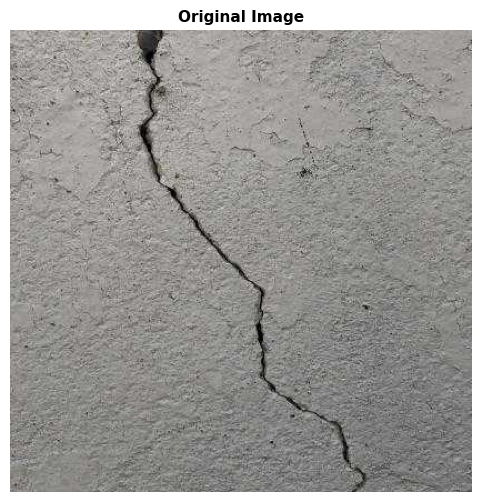

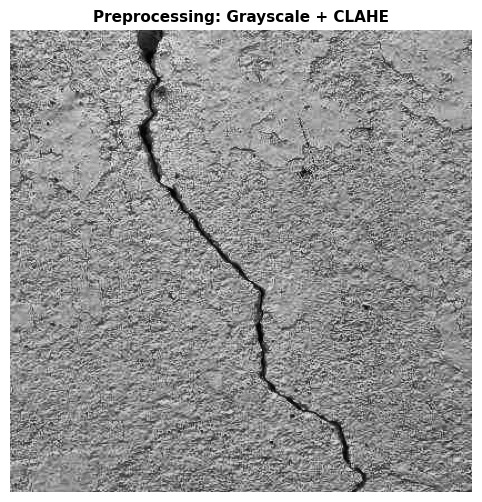

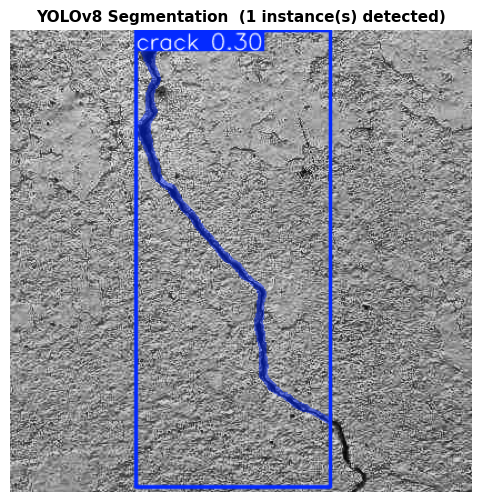

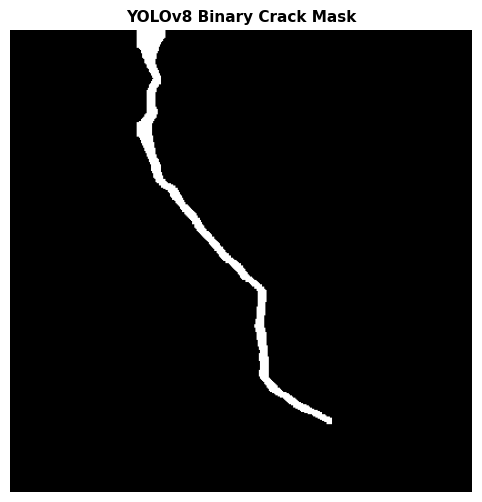

  ✓ 1 structural crack(s) passed ACI filter, 0 rejected.


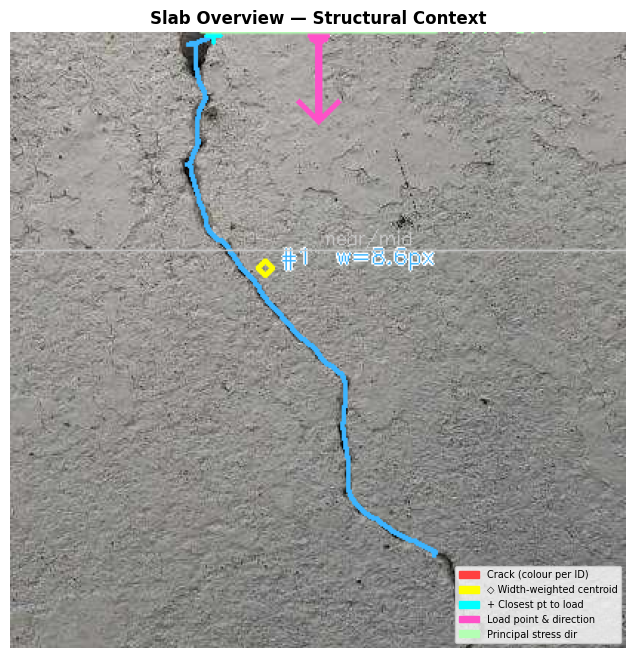

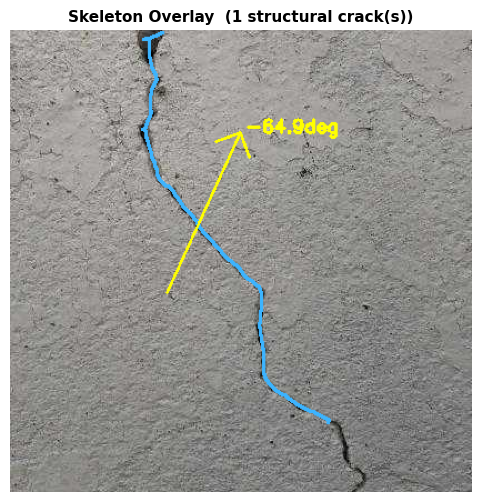

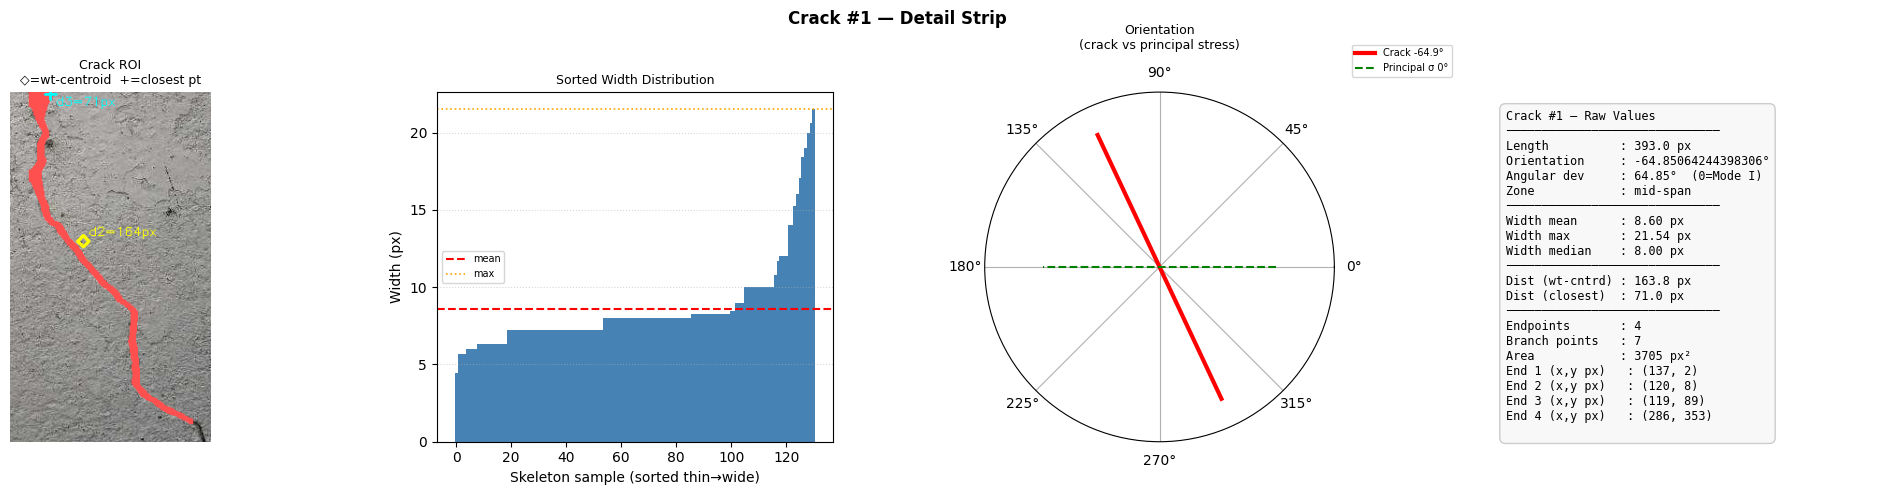

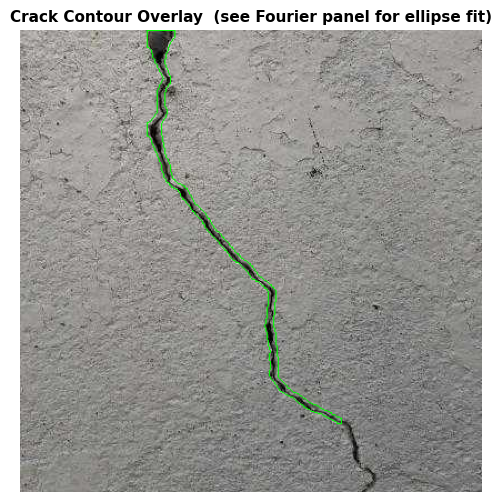

/var/folders/m5/0r5qznn979n6dtrkyb1fjtxw0000gn/T/ipykernel_6024/105366033.py:235: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.96])


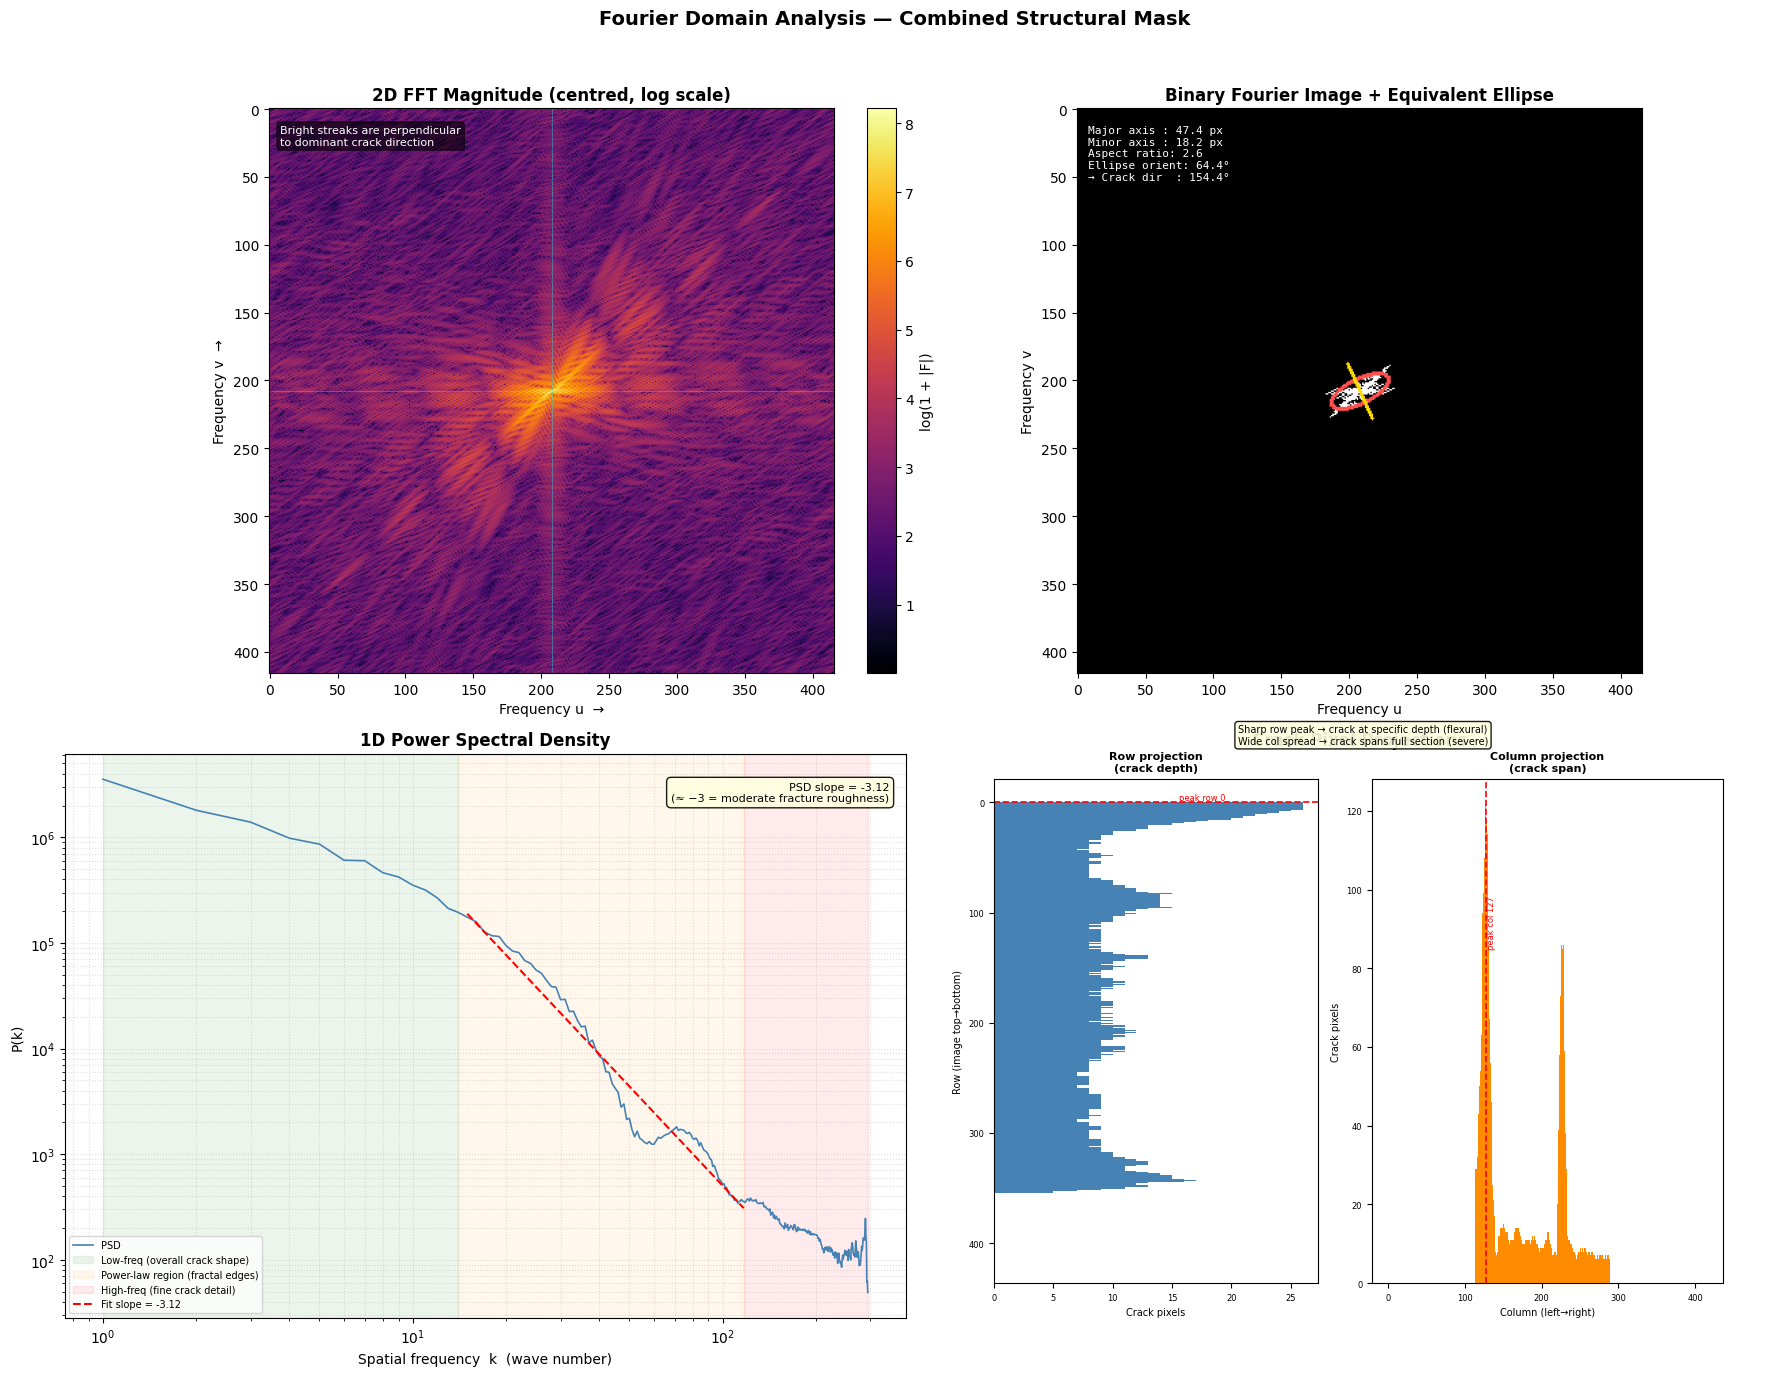

  CRACK ANALYSIS RESULTS  –  2386.rf.27c59ea07f58cb1643d9e70e3e468562.jpg

Load point (px)      : (208, 0)
Load direction       : 90°
Principal stress dir : 0°

Structural cracks    : 1
Rejected (non-struct): 0

── Crack #1 ────────────────────────────────────────
  Length (px)              : 393.0
  Orientation (deg)        : -64.85064244398306
  Angular dev from Mode I  : 64.85°
  Slab zone                : mid-span
  Width mean/max/med (px)  : 8.60 / 21.54 / 8.00
  Dist wt-centroid→load    : 163.8 px
  Dist closest pt→load     : 71.0 px
  Endpoints / Branch pts   : 4 / 7
    Endpoint 1 (x,y px)    : (137, 2)
    Endpoint 2 (x,y px)    : (120, 8)
    Endpoint 3 (x,y px)    : (119, 89)
    Endpoint 4 (x,y px)    : (286, 353)

── Fourier Analysis ───────────────────────────────────
  PSD slope                : (see plot)
  Ellipse major axis       : 47.4 px
  Ellipse minor axis       : 18.2 px
  Aspect ratio             : 2.6
  Ellipse orientation      : 64.4°
  Crack dir (Fourier)    

In [17]:
image_to_process   = Path('/Users/adityagk/Desktop/UniRGV_internship/cv_pipeline_pinn/datasets/crack-seg/images/val/2386.rf.27c59ea07f58cb1643d9e70e3e468562.jpg')
LOAD_POINT_NORM    = (0.5, 0.0)   # <── update: where the load is applied
LOAD_DIRECTION_DEG = 90            # <── update: which way the load acts

# ── Output directory ─────────────────────────────────────────────────────
timestamp        = datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
output_directory = OUTPUT_DIR / timestamp
output_directory.mkdir(parents=True, exist_ok=True)
print(f'Outputs will be saved in: {output_directory}\n')

if not image_to_process.exists():
    sample_images = list(INPUT_DIR.glob('*.*'))
    if sample_images:
        image_to_process = sample_images[0]
        print(f'Using found sample image: {image_to_process}\n')

if image_to_process.exists():
    process_image(
        image_to_process,
        out_dir=output_directory,
        load_point_norm=LOAD_POINT_NORM,
        load_direction_deg=LOAD_DIRECTION_DEG,
        yolo_conf=YOLO_CONF,
        yolo_iou=YOLO_IOU,
        clahe_clip=2.0,
        clahe_tile=(8, 8),
    )
else:
    print(f'Could not find image at {image_to_process}. Update the path above.')
